# Notebook 05 : Interprétabilité et exploitabilité du modèle

## Sommaire

1.  Introduction
2.  Chargement du modèle final et des données
3.  Rappel du modèle retenu
4.  Analyse des coefficients de la Régression Logistique
5.  Classement des variables influentes
6.  Visualisation de l'importance des variables
7.  Interprétation métier des résultats
8.  Analyse des erreurs de classification
9.  Explication de prédictions individuelles
10. Analyse SHAP (optionnel mais recommandé)
11. Conclusion du notebook

## 1. Introduction

Objectif

Après avoir construit, évalué et sélectionné le modèle final, il est nécessaire de comprendre son fonctionnement interne.

L'objectif de ce notebook est d'analyser :

-   quelles variables influencent le plus les prédictions ;
-   dans quel sens elles influencent la probabilité de survie ;
-   pourquoi certaines observations sont correctement ou incorrectement classées.
-   L'interprétabilité est une étape essentielle dans un projet Machine Learning professionnel, car un modèle performant doit également être compréhensible et explicable.

***Problématique***

Le modèle doit répondre à la question : Quels facteurs expliquent la probabilité de survie d'un passager du Titanic ?


## 2. Chargement des bibliothèques

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import load

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

## 3. Chargement du modèle final

Nous rechargeons le modèle sélectionné dans le notebook 04.

In [2]:
model = load(
    "../models/logistic_regression_baseline.pkl"
)

### Vérification

In [3]:
model

LogisticRegression(random_state=42)

## 4. Chargement des données

Nous avons besoin des données après preprocessing.

In [4]:
X_test = pd.read_csv(
    "../data/processed/X_test_less_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test_less.csv"
)

In [9]:
y_test =y_test.squeeze()

## 5. Rappel du modèle retenu 

Avant d'interpréter, rappelons pourquoi ce modèle a été choisi.

Dans le notebook 04 :

-   plusieurs modèles ont été comparés ;
-   une optimisation a été réalisée ;
-   le modèle optimisé n'a pas amélioré les performances.
-   Le modèle final retenu est donc : Reglog_Baseline

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Prédictions
y_pred = model.predict(X_test)

# Probabilités
y_proba = model.predict_proba(X_test)[:, 1]

# Tableau des performances
performance = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Valeur": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]
})

performance 

,Métrique,Valeur
0,Accuracy,0.837989
1,Precision,0.803030
2,Recall,0.768116
3,F1-score,0.785185
4,ROC-AUC,0.873781


## 6. Analyse des coefficients du modèle

### 6.1 Principe

La Régression Logistique utilise une équation :

![Computer](../formule.png)
​	
 
Chaque coefficient :
-   positif → augmente la probabilité de survie ;
-   négatif → diminue la probabilité de survie.

### 6.2 Extraction des coefficients

Le modèle possède :



In [11]:
model.coef_

array([[-0.60672912,  0.51560743, -0.3905061 , -0.33022017, -0.15192558,
         0.10700581,  0.39045478, -0.30056073, -0.1595829 ,  0.08804048,
        -0.14050736, -0.40538515, -1.33249776, -0.0980022 , -0.3071765 ]])

Cependant, il faut associer chaque coefficient à une variable.

Récupération des noms :

In [12]:
feature_names = X_test.columns

Création du DataFrame :

In [13]:
coefficients = pd.DataFrame({

    "Variable": feature_names,

    "Coefficient": model.coef_[0]

})

Afficher :

In [14]:
coefficients.head()


,Variable,Coefficient
0,Pclass,-0.606729
1,Sex,0.515607
2,Age,-0.390506
3,SibSp,-0.330220
4,Parch,-0.151926


## 7. Classement des variables importantes

Nous ajoutons la valeur absolue du coefficient.

Pourquoi ?

Car une variable peut être fortement négative ou fortement positive.
L'importance dépend de : **|Coefficient|**



In [15]:
coefficients["Importance"] = (
    coefficients["Coefficient"]
    .abs()
)

Tri :

In [16]:
coefficients_sorted = (
    coefficients
    .sort_values(
        by="Importance",
        ascending=False
    )
)

Afficher :

In [17]:
coefficients_sorted

,Variable,Coefficient,Importance
12,Title_Mr,-1.332498,1.332498
0,Pclass,-0.606729,0.606729
1,Sex,0.515607,0.515607
11,Title_Miss,-0.405385,0.405385
2,Age,-0.390506,0.390506
6,Cabin_known,0.390455,0.390455
3,SibSp,-0.330220,0.330220
14,Title_Rare,-0.307176,0.307176
7,FamilySize,-0.300561,0.300561
8,IsAlone,-0.159583,0.159583


## 8. Visualisation des coefficients

Graphique des variables les plus influentes, on affiche les 15 variables principales.


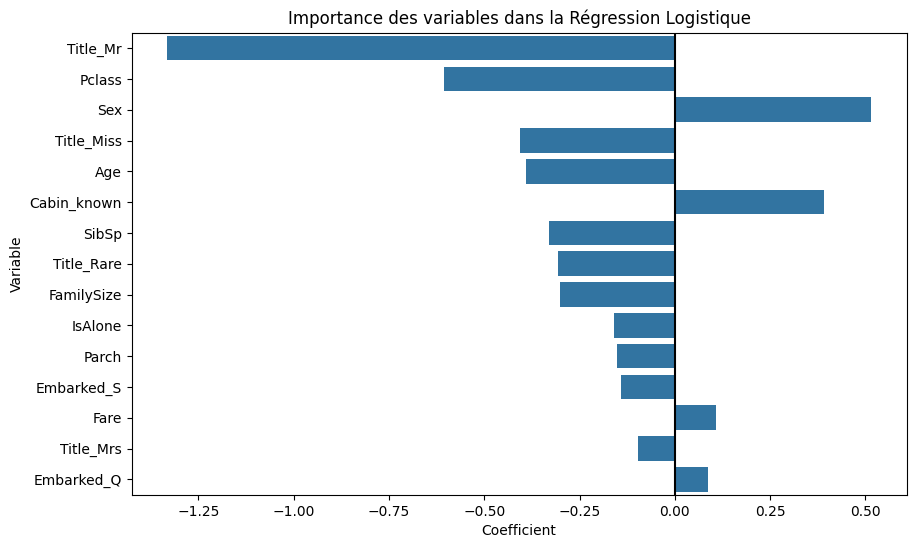

In [18]:
top_features = coefficients_sorted.head(15)


plt.figure(figsize=(10,6))


sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Variable"
)


plt.title(
    "Importance des variables dans la Régression Logistique"
)

plt.axvline(
    0,
    color="black"
)


plt.show()

Interprétation du graphique : 

Variables à droite :
→ augmentent la probabilité de survie.

Variables à gauche :
→ diminuent la probabilité de survie.

## 9. Analyse métier des résultats

Cette partie est essentielle.

Exemple de conclusion :

### Sexe (0 = male, 1 = female)

coef_sex = 0.51 --> le modèle considère que être une femme constitue un facteur favorable à la survie.

Ce résultat est cohérent avec le contexte historique du naufrage du Titanic, 
où la règle « Women and children first » a conduit 
à prioriser l'évacuation des femmes et des enfants vers les canots de sauvetage.



### Classe du billet (Pclass)

le coefficient de Pclass est de -0.60, ce qui signifie que plus la classe est basse (pclass qui augmente) plus cela est défavorable à la survie, ce qui est logique d'un point de vue métier. 

## 10. Analyse des erreurs du modèle

Maintenant nous analysons les erreurs.

### Prédictions

In [31]:
y_pred = model.predict(
    X_test
)

### Matrice de confusion

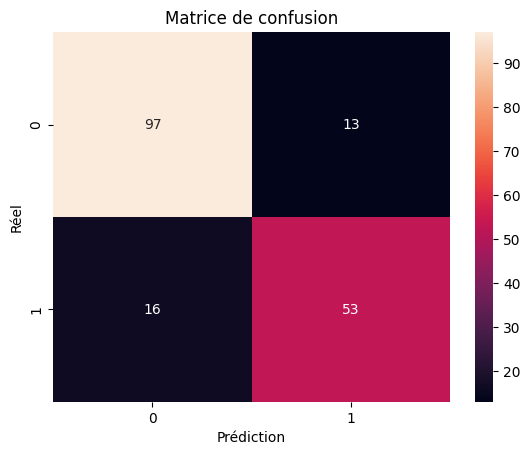

In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Prédiction"
)

plt.ylabel(
    "Réel"
)

plt.title(
    "Matrice de confusion"
)

plt.show()

#### Interprétation

Nous cherchons :

-   FP(faux positifs) : le code prédit une survie mais n'a pas survécu
-   FN(faux négatifs) : le code prédit une mort mais a survécu

## 11. Analyse de quelques erreurs

Création d'un tableau :

In [33]:
errors = X_test.copy()

errors["Réel"] = y_test.values

errors["Prédit"] = y_pred

Faux positifs :

In [34]:
false_positive = errors[
    (errors["Réel"]==0)
    &
    (errors["Prédit"]==1)
]

false_positive.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Réel,Prédit
7,-1.571457,-0.742427,1.193063,-0.465084,-0.466183,-0.109730,1.857418,-0.556339,0.800346,-0.289333,0.611978,-0.503509,-1.171893,-0.420547,6.209312,0,1
41,-1.571457,1.346933,-2.108175,0.478335,1.921748,2.493062,1.857418,1.332913,-1.249460,-0.289333,0.611978,1.986063,-1.171893,-0.420547,-0.161048,0,1
47,0.829568,1.346933,0.809198,0.478335,-0.466183,-0.465272,-0.538382,0.073412,-1.249460,-0.289333,0.611978,-0.503509,-1.171893,2.377857,-0.161048,0,1
51,0.829568,1.346933,-0.112078,-0.465084,-0.466183,-0.494943,-0.538382,-0.556339,0.800346,-0.289333,0.611978,1.986063,-1.171893,-0.420547,-0.161048,0,1
52,0.829568,1.346933,-0.112078,-0.465084,-0.466183,-0.503705,-0.538382,-0.556339,0.800346,3.456220,-1.634045,1.986063,-1.171893,-0.420547,-0.161048,0,1


Faux négatifs :

In [35]:
false_negative = errors[
    (errors["Réel"]==1)
    &
    (errors["Prédit"]==0)
]

false_negative.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Réel,Prédit
2,0.829568,-0.742427,-0.572716,-0.465084,-0.466183,-0.512122,-0.538382,-0.556339,0.800346,-0.289333,-1.634045,-0.503509,0.85332,-0.420547,-0.161048,1,0
27,-1.571457,-0.742427,1.423382,0.478335,-0.466183,0.420198,1.857418,0.073412,-1.249460,-0.289333,0.611978,-0.503509,0.85332,-0.420547,-0.161048,1,0
28,0.829568,-0.742427,-0.035305,-0.465084,-0.466183,-0.498154,-0.538382,-0.556339,0.800346,-0.289333,-1.634045,-0.503509,0.85332,-0.420547,-0.161048,1,0
53,-0.370945,-0.742427,-0.112078,-0.465084,-0.466183,-0.391873,-0.538382,-0.556339,0.800346,-0.289333,0.611978,-0.503509,0.85332,-0.420547,-0.161048,1,0
57,-1.571457,-0.742427,0.425333,-0.465084,-0.466183,-0.115196,1.857418,-0.556339,0.800346,-0.289333,0.611978,-0.503509,0.85332,-0.420547,-0.161048,1,0


## 12. SHAP (optionnel mais très valorisant)



In [36]:
import shap


Création de l'explainer :

In [37]:
explainer = shap.Explainer(
    model,
    X_test
)

Calcul :

In [38]:
shap_values = explainer(
    X_test
)

Résumé global :

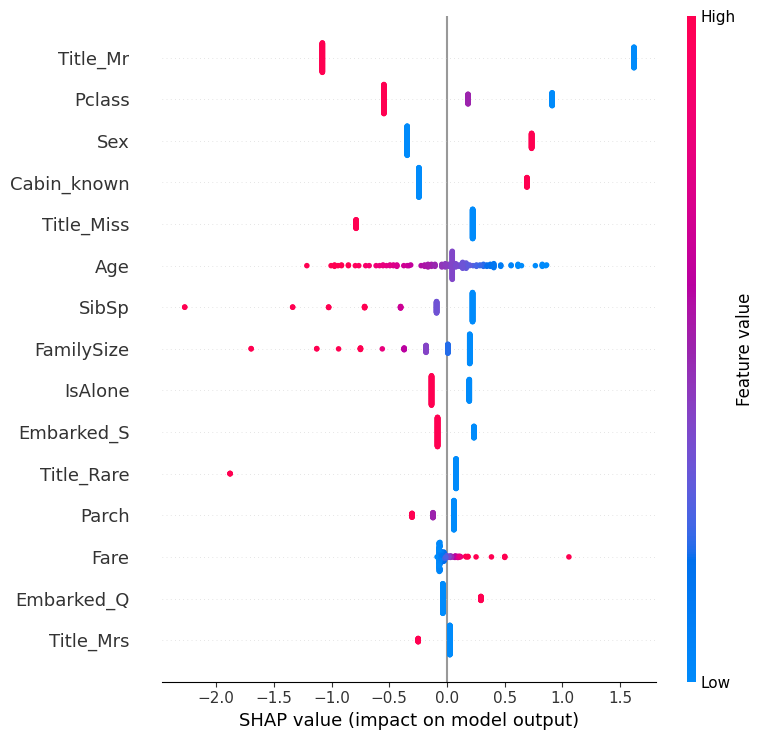

In [39]:
shap.summary_plot(
    shap_values,
    X_test
)

Cela montre :

-   importance globale ;
-   direction de l'effet ;
-   impact de chaque variable.

## 13. Conclusion du Notebook 05

Ce notebook a permis d'analyser et d'interpréter le comportement du modèle final de Régression Logistique. L'étude des coefficients a permis d'identifier les variables ayant le plus d'influence sur les prédictions.

Les résultats montrent que certaines caractéristiques, notamment le sexe, la classe du billet et les variables liées au niveau social, jouent un rôle majeur dans la probabilité de survie. Ces observations sont cohérentes avec le contexte historique du naufrage du Titanic.

L'analyse des erreurs a également permis d'identifier les situations dans lesquelles le modèle rencontre des difficultés, notamment certains profils atypiques ou ambigus.

Cette étape confirme que le modèle n'est pas seulement performant, mais également interprétable, ce qui est essentiel dans un contexte professionnel où la compréhension des décisions algorithmiques est indispensable.